# <div style="background-color: #EBF5FB; padding: 25px; border-radius: 15px; color: #2874A6; text-align: center; font-family: 'Segoe UI', sans-serif; border: 1px solid #AED6F1;"> Generative HR Analytics : Prédiction du Turnover</div>

<br>

<div style="text-align: center; font-family: sans-serif; color: #5D6D7E;">
    <span style="background-color: #F4F6F7; padding: 5px 15px; border-radius: 20px; border: 1px solid #D5DBDB;"> <b>UCAO 2025-2026</b></span>
    <span style="margin-left: 10px; background-color: #F4F6F7; padding: 5px 15px; border-radius: 20px; border: 1px solid #D5DBDB;"> Encadreur : <b>M. Aidara</b></span>
</div>

<div style="text-align: center; margin-top: 15px; color: #34495E; font-size: 1.1em;">
     <b>Seye Kiné & Bindia Adeline Thiara</b>
</div>

---

### <span style="color: #2E86C1;"> Objectif</span>
<p style="color: #5D6D7E; font-size: 1.1em; border-left: 4px solid #AED6F1; padding-left: 15px;">
    Prédire si un employé va quitter l'entreprise et expliquer les causes du départ grâce à l'IA pour orienter les décisions RH.
</p>

---

### <span style="color: #2E86C1;"> Plan du Notebook</span>

<table style="width:100%; border-collapse: collapse; font-family: sans-serif;">
  <thead>
    <tr style="border-bottom: 2px solid #AED6F1;">
      <th style="padding: 15px; text-align: left; color: #21618C;">Phase</th>
      <th style="padding: 15px; text-align: left; color: #21618C;">Détails</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #FDFEFE;">
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #2E86C1; font-weight: bold;">01. Exploration</td>
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #5D6D7E;">Chargement et premier regard sur les 19 variables.</td>
    </tr>
    <tr style="background-color: #F7FBFE;">
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #2E86C1; font-weight: bold;">02. Analyse</td>
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #5D6D7E;">Identification des facteurs clés (corrélation, statistiques).</td>
    </tr>
    <tr style="background-color: #FDFEFE;">
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #2E86C1; font-weight: bold;">03. Engineering</td>
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #5D6D7E;">Nettoyage, encodage et découpage Train/Test.</td>
    </tr>
    <tr style="background-color: #F7FBFE;">
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #2E86C1; font-weight: bold;">04. Modélisation</td>
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #5D6D7E;">Entraînement de 4 modèles de Machine Learning.</td>
    </tr>
    <tr style="background-color: #FDFEFE;">
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #2E86C1; font-weight: bold;">05. Optimisation</td>
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #5D6D7E;">Ajustement des hyperparamètres du meilleur modèle.</td>
    </tr>
    <tr style="background-color: #F7FBFE;">
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #2E86C1; font-weight: bold;">06. Évaluation</td>
      <td style="padding: 12px; border-bottom: 1px solid #EAEDED; color: #5D6D7E;">Analyse des performances (Matrice, AUC, F1-Score).</td>
    </tr>
    <tr style="background-color: #EBF5FB;">
      <td style="padding: 12px; color: #1B4F72; font-weight: bold;">07. Explicabilité</td>
      <td style="padding: 12px; color: #1B4F72;"><b>Interprétation SHAP</b> pour la transparence des décisions.</td>
    </tr>
  </tbody>
</table>

<br>

<div style="background-color: #F4F6F7; padding: 10px; border-radius: 8px; font-size: 0.9em; color: #7F8C8D; text-align: center;">
     <b>Données :</b> 10 000 entrées | 19 colonnes | hr_turnover.csv
</div>

**Cellule 0 Import des bibliothéques**

In [1]:
# Manipulation des données

import pandas as pd
import numpy as np

#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# Explicabilité
import shap

# Divers
import warnings
warnings.filterwarnings('ignore')

print(" Toutes les bibliothèques sont chargées")


 Toutes les bibliothèques sont chargées


**Etape 1 Chargement et EXploration des données**

**ojectif:** carger le chichier CSV et comprendre ce qu'il contient

In [2]:
# chargement du fichier
df = pd.read_csv('hr.csv')

In [3]:
#Vérifier si on a assez d'employés pour que l'étude soit fiable.
print(f" : {df.shape[0]:,} lignes")

 : 1,470 lignes


In [4]:
print(f" : {df.shape[1]:,} colonnes")

 : 31 colonnes


In [5]:
#Lister tout ce que l'on sait sur les employés (âge, salaire, stress, etc.).
print("colonnes disponibles :")
for col in df.columns:
    print(f" - {col}")

colonnes disponibles :
 - Age
 - Attrition
 - BusinessTravel
 - DailyRate
 - Department
 - DistanceFromHome
 - Education
 - EducationField
 - EnvironmentSatisfaction
 - Gender
 - HourlyRate
 - JobInvolvement
 - JobLevel
 - JobRole
 - JobSatisfaction
 - MaritalStatus
 - MonthlyIncome
 - MonthlyRate
 - NumCompaniesWorked
 - OverTime
 - PercentSalaryHike
 - PerformanceRating
 - RelationshipSatisfaction
 - StockOptionLevel
 - TotalWorkingYears
 - TrainingTimesLastYear
 - WorkLifeBalance
 - YearsAtCompany
 - YearsInCurrentRole
 - YearsSinceLastPromotion
 - YearsWithCurrManager


In [6]:
## Visualisation des premières données pour détecter d'éventuelles anomalies de saisie
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,...,Excellent,Very High,1,6,3,Better,2,2,2,2


In [7]:
#Dresser le portrait-robot de l'employé moyen.
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,65.89,6502.93,14313.10,2.69,15.21,0.79,11.28,2.80,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,20.33,4707.96,7117.79,2.50,3.66,0.85,7.78,1.29,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,30.00,1009.00,2094.00,0.00,11.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,48.00,2911.00,8047.00,1.00,12.00,0.00,6.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,66.00,4919.00,14235.50,2.00,14.00,1.00,10.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,83.75,8379.00,20461.50,4.00,18.00,1.00,15.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,100.00,19999.00,26999.00,9.00,25.00,3.00,40.00,6.00,40.00,18.00,15.00,17.00


In [8]:
#On vérifie qu'il n'y a pas de trous (valeurs manquantes) ou d'employés comptés deux fois (doublons) pour ne pas fausser les résultats.
print("=== QUALITE DE DONNEES ===")
print(f"Valeur manquantes : {df.isnull().sum()}")
print(f"Doublons           : {df.duplicated().sum()}")
print()


=== QUALITE DE DONNEES ===
Valeur manquantes : Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64
Doublons  

In [9]:
# Conversion de la variable cible : Yes → 1, No → 0
# Les modèles ML ne comprennent que des chiffres
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [10]:
#Avant de prédire l'avenir, on regarde exactement combien d'employés sont déjà partis. 
#Cela permet de savoir si le problème de départ est grave ou non dans l'entreprise.
n_total = len(df)
n_reste = (df['Attrition'] ==0).sum()
n_part = (df['Attrition'] ==1).sum()
taux   = n_part / n_total * 100

print("=== VARIABLE CIBLE : Attrition ===")
print()
print(f"Restés (0) : {n_reste:,} employés ({100-taux:.1f}%)")
print()
print(f"Partiss (1) : {n_part:,} employés ({taux:.1f}%)")
print()
print(f"Taux d'attrition : {taux:.1f}%")

=== VARIABLE CIBLE : Attrition ===

Restés (0) : 1,233 employés (83.9%)

Partiss (1) : 237 employés (16.1%)

Taux d'attrition : 16.1%


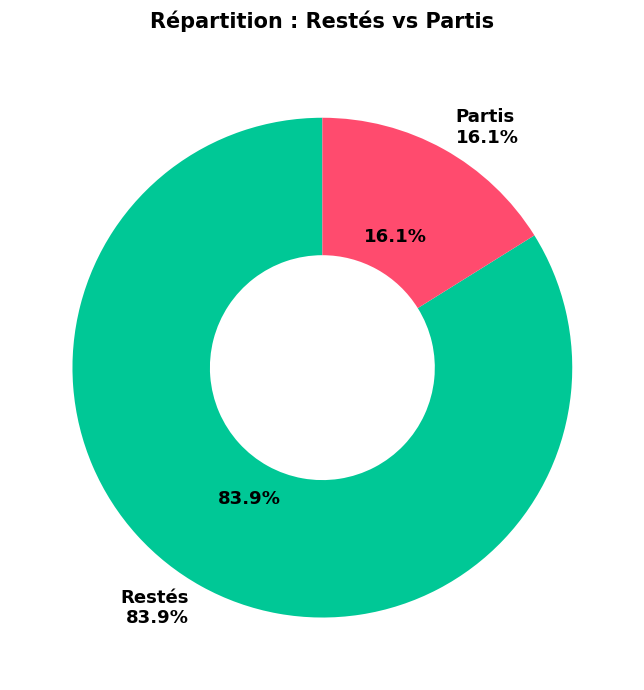

In [11]:
# Visualisation de la répartition
 

# On utilise un Donut pour voir d'un coup d'œil si les départs sont minoritaires
# ou s'ils représentent une part inquiétante du personnel.
plt.figure(figsize=(7, 7))
sizes  = [n_reste, n_part]
labels = [f'Restés\n{100-taux:.1f}%', f'Partis\n{taux:.1f}%']
colors = ['#00C896', '#FF4B6E']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(width=0.55),
        textprops=dict(fontsize=13, fontweight='bold'))
plt.title("Répartition : Restés vs Partis", fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()



---
## Étape 2 — Analyse des facteurs de départ

**Objectif :** Identifier quelles variables sont vraiment liées aux départs.

**Méthode :** Test de Mann-Whitney (test non-paramétrique).
- Si **p-value < 0.05** → la variable est liée aux départs 
- Si **p-value ≥ 0.05** → pas de lien significatif 

In [12]:
from scipy.stats import mannwhitneyu

# 1. Sélectionner tous les indicateurs chiffrés pour identifier les leviers d'influence
COLS_NUM = [  'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]
# 2. Séparer l'échantillon en deux groupes pour comparer leurs comportements
groupe_reste = df[df['Attrition'] == 0]
groupe_part  = df[df['Attrition'] == 1]

print(f"{'Variable':<35} {'p-value':>10}  Résultat")
print("-" * 65)

vars_sig = []

# 3. Appliquer le test de Mann-Whitney pour valider scientifiquement chaque variable
for var in COLS_NUM:
    # On calcule la probabilité (p-value) que la différence soit un pur hasard
    _, p = mannwhitneyu(groupe_reste[var], groupe_part[var], alternative='two-sided')
    
    # Seuil de 5% : si p < 0.05, l'influence de la variable est statistiquement prouvée
    sig = " *** Significatif" if p < 0.05 else " Non significatif"
    print(f"{var:<35} {p:>10.4f}  {sig}")
    
    if p < 0.05:
        vars_sig.append(var)

# 4. Bilan des découvertes
print()
print(f"Total des variables ayant un impact prouvé : {len(vars_sig)} / {len(COLS_NUM)}")
print(f"Liste pour le modèle : {vars_sig}")

Variable                               p-value  Résultat
-----------------------------------------------------------------
Age                                     0.0000   *** Significatif
DailyRate                               0.0290   *** Significatif
DistanceFromHome                        0.0024   *** Significatif
HourlyRate                              0.7976   Non significatif
MonthlyIncome                           0.0000   *** Significatif
MonthlyRate                             0.5587   Non significatif
NumCompaniesWorked                      0.2424   Non significatif
PercentSalaryHike                       0.3655   Non significatif
StockOptionLevel                        0.0000   *** Significatif
TotalWorkingYears                       0.0000   *** Significatif
TrainingTimesLastYear                   0.0473   *** Significatif
YearsAtCompany                          0.0000   *** Significatif
YearsInCurrentRole                      0.0000   *** Significatif
YearsSinceLastPromo

In [13]:
# Corrélations de chaque variable numérique avec l'Attrition
corr = df[COLS_NUM + ['Attrition']].corr()['Attrition'].drop('Attrition')

print("=== CORRÉLATIONS AVEC L'ATTRITION ===")
print()
# sort_values() sans argument → tri croissant par défaut
for var, val in corr.sort_values().items():
    barre = "█" * int(abs(val) * 60)
    sens  = "↑ plus de départs" if val > 0 else "↓ moins de départs"
    print(f"  {var:<35} {val:+.4f}  {barre}  {sens}")


=== CORRÉLATIONS AVEC L'ATTRITION ===

  TotalWorkingYears                   -0.1711  ██████████  ↓ moins de départs
  YearsInCurrentRole                  -0.1605  █████████  ↓ moins de départs
  MonthlyIncome                       -0.1598  █████████  ↓ moins de départs
  Age                                 -0.1592  █████████  ↓ moins de départs
  YearsWithCurrManager                -0.1562  █████████  ↓ moins de départs
  StockOptionLevel                    -0.1371  ████████  ↓ moins de départs
  YearsAtCompany                      -0.1344  ████████  ↓ moins de départs
  TrainingTimesLastYear               -0.0595  ███  ↓ moins de départs
  DailyRate                           -0.0567  ███  ↓ moins de départs
  YearsSinceLastPromotion             -0.0330  █  ↓ moins de départs
  PercentSalaryHike                   -0.0135    ↓ moins de départs
  HourlyRate                          -0.0068    ↓ moins de départs
  MonthlyRate                         +0.0152    ↑ plus de départs
  NumComp

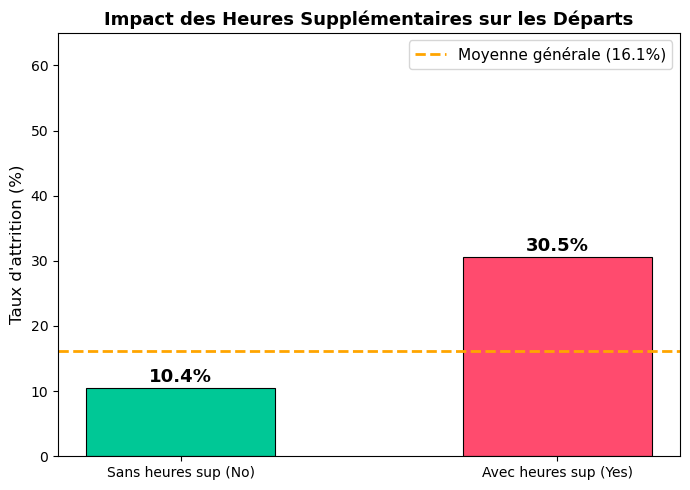


  Sans heures sup : 10.4%
  Avec heures sup : 30.5%
  → Différence : +20.1 points — facteur #1 de risque


In [14]:
# 1. Calculer l'impact réel du temps de travail sur la décision de quitter l'entreprise
# On regroupe par 'OverTime' pour comparer le taux moyen de départ (Attrition)
ot_taux = df.groupby('OverTime')['Attrition'].mean() * 100

plt.figure(figsize=(7, 5))

# 2. Visualiser la différence pour rendre le problème immédiatement compréhensible
# Le Vert (No) vs le Rouge (Yes) permet de désigner visuellement la zone de danger
barres = plt.bar(['Sans heures sup (No)', 'Avec heures sup (Yes)'],
                  ot_taux.values,
                  color=['#00C896', '#FF4B6E'],
                  edgecolor='black', linewidth=0.8, width=0.5)

# 3. Ajouter une ligne de référence (moyenne générale)
# Cela sert à prouver que le groupe "Avec heures sup" est anormalement au-dessus de la normale
plt.axhline(y=taux, color='orange', linestyle='--', 
            linewidth=2, label=f'Moyenne générale ({taux:.1f}%)')

plt.ylabel("Taux d'attrition (%)", fontsize=12)
plt.title("Impact des Heures Supplémentaires sur les Départs", 
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0, 65)

# 4. Afficher les chiffres exacts au-dessus des barres pour la précision du rapport
for barre, v in zip(barres, ot_taux.values):
    plt.text(barre.get_x() + barre.get_width()/2, v + 1, 
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# 5. Conclusion chiffrée pour justifier les recommandations RH
print()
diff = ot_taux['Yes'] - ot_taux['No']
print(f"  Sans heures sup : {ot_taux['No']:.1f}%")
print(f"  Avec heures sup : {ot_taux['Yes']:.1f}%")
print(f"  → Différence : +{diff:.1f} points — facteur #1 de risque")

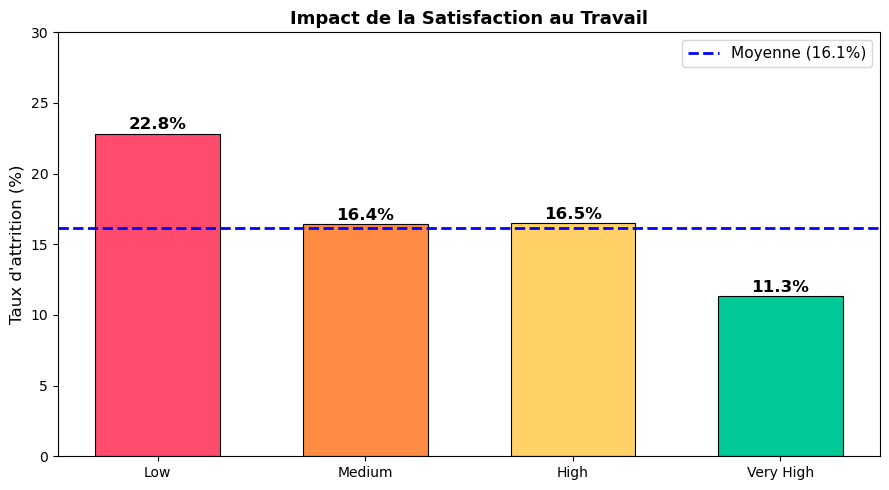

 SYNTHÈSE DES LEVIERS DE RÉTENTION
Nombre de variables analysées : 15
Variables avec impact prouvé  : 11
------------------------------------------------------------
  [IMPACT] : Age                       (p-value < 0.05)
  [IMPACT] : DailyRate                 (p-value < 0.05)
  [IMPACT] : DistanceFromHome          (p-value < 0.05)
  [IMPACT] : MonthlyIncome             (p-value < 0.05)
  [IMPACT] : StockOptionLevel          (p-value < 0.05)
  [IMPACT] : TotalWorkingYears         (p-value < 0.05)
  [IMPACT] : TrainingTimesLastYear     (p-value < 0.05)
  [IMPACT] : YearsAtCompany            (p-value < 0.05)
  [IMPACT] : YearsInCurrentRole        (p-value < 0.05)
  [IMPACT] : YearsSinceLastPromotion   (p-value < 0.05)
  [IMPACT] : YearsWithCurrManager      (p-value < 0.05)
------------------------------------------------------------
 Conseil : Concentrez vos actions prioritaires sur ces indicateurs.


In [15]:
# Impact de la satisfaction au travail sur les départs
# Dans hr.csv : Low, Medium, High, Very High (pas 1/2/3/4)

ordre_js = ['Low', 'Medium', 'High', 'Very High']
js_taux  = df.groupby('JobSatisfaction')['Attrition'].mean() * 100
js_taux  = js_taux.reindex(ordre_js)

plt.figure(figsize=(9, 5))
barres = plt.bar(
    ordre_js, js_taux.values,
    color=['#FF4B6E', '#FF8C42', '#FFD166', '#00C896'],
    edgecolor='black', linewidth=0.8, width=0.6
)

# 3. Positionner la moyenne pour identifier quels niveaux de satisfaction sont critiques
# Si une barre dépasse cette ligne bleue, le niveau de satisfaction est insuffisant
plt.axhline(y=taux, color='blue', linestyle='--', linewidth=2,
            label=f'Moyenne ({taux:.1f}%)')
plt.ylabel("Taux d'attrition (%)", fontsize=12)
plt.title("Impact de la Satisfaction au Travail", fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0, 30)
for b, v in zip(barres, js_taux.values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.3,
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


print("="*60)
print(" SYNTHÈSE DES LEVIERS DE RÉTENTION")
print("="*60)
print(f"Nombre de variables analysées : {len(COLS_NUM)}")
print(f"Variables avec impact prouvé  : {len(vars_sig)}")
print("-" * 60)

# Lister les variables significatives avec un petit commentaire
for var in vars_sig:
    print(f"  [IMPACT] : {var:<25} (p-value < 0.05)")

print("-" * 60)
print(" Conseil : Concentrez vos actions prioritaires sur ces indicateurs.")



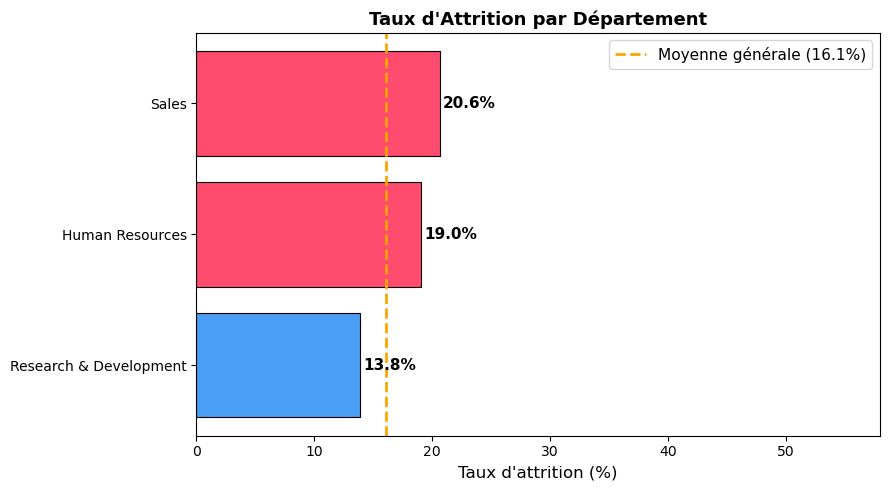


  Département le plus à risque : Sales (20.6%)
  Département le plus stable   : Research & Development (13.8%)


In [16]:
# 1. Comparer la stabilité des différents pôles de l'entreprise
# On calcule la moyenne de départ par département pour voir si le problème est localisé
dept_taux  = df.groupby('Department')['Attrition'].mean() * 100
dept_taux  = dept_taux.sort_values(ascending=True)

# 2. Utiliser un code couleur pour identifier immédiatement les départements "hors normes"
# Rouge si le taux dépasse la moyenne nationale de l'entreprise, bleu sinon
colors_d   = ['#FF4B6E' if v > taux else '#4A9EF5' for v in dept_taux.values]

plt.figure(figsize=(9, 5))
barres = plt.barh(dept_taux.index, dept_taux.values, 
                   color=colors_d, edgecolor='black', linewidth=0.8)

# 3. Tracer la frontière de performance (la moyenne)
plt.axvline(x=taux, color='orange', linestyle='--', 
            linewidth=2, label=f'Moyenne générale ({taux:.1f}%)')

plt.xlabel("Taux d'attrition (%)", fontsize=12)
plt.title("Taux d'Attrition par Département", 
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.xlim(0, 58)

# 4. Afficher les scores pour une lecture directe lors de la soutenance
for barre, v in zip(barres, dept_taux.values):
    plt.text(v + 0.3, barre.get_y() + barre.get_height()/2, 
             f'{v:.1f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# 5. Résumé des points critiques pour la conclusion
print()
dept_max = dept_taux.idxmax()
dept_min = dept_taux.idxmin()
print(f"  Département le plus à risque : {dept_max} ({dept_taux[dept_max]:.1f}%)")
print(f"  Département le plus stable   : {dept_min} ({dept_taux[dept_min]:.1f}%)")

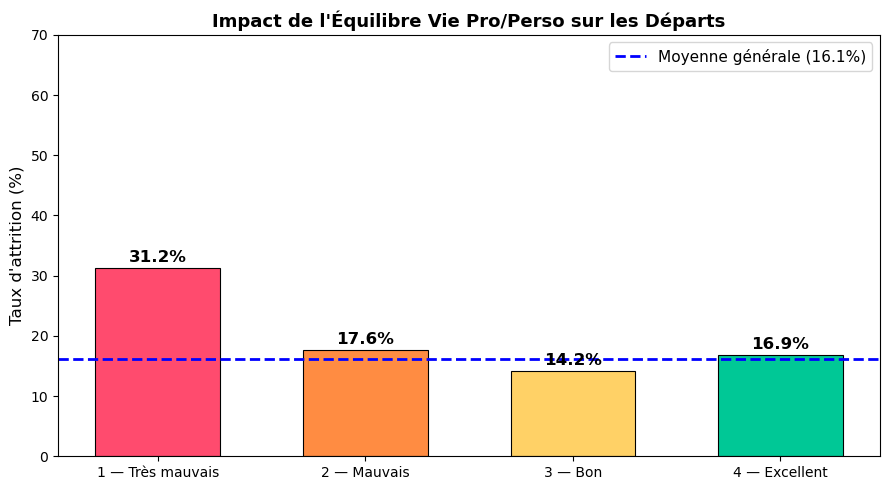

In [17]:
# Graphique 5 : Attrition selon l'Équilibre Vie Pro/Perso (WorkLifeBalance)
wlb_taux   = df.groupby('WorkLifeBalance')['Attrition'].mean() * 100
labels_wlb = ['1 — Très mauvais', '2 — Mauvais', '3 — Bon', '4 — Excellent']
colors_wlb = ['#FF4B6E', '#FF8C42', '#FFD166', '#00C896']

plt.figure(figsize=(9, 5))
barres = plt.bar(labels_wlb, wlb_taux.values,
                  color=colors_wlb, edgecolor='black', linewidth=0.8, width=0.6)
plt.axhline(y=taux, color='blue', linestyle='--',
            linewidth=2, label=f'Moyenne générale ({taux:.1f}%)')
plt.ylabel("Taux d'attrition (%)", fontsize=12)
plt.title("Impact de l'Équilibre Vie Pro/Perso sur les Départs",
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0, 70)
for barre, v in zip(barres, wlb_taux.values):
    plt.text(barre.get_x() + barre.get_width()/2, v + 1,
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# Profils extrêmes : combinaisons de facteurs
print("=== ANALYSE DES PROFILS EXTRÊMES ===")
print()

# Profil critique : heures sup + faible satisfaction + mauvais WLB
profil_crit = df[
    (df['OverTime'] == 'Yes') &
    (df['JobSatisfaction'].isin(['Low', 'Medium'])) &
    (df['WorkLifeBalance'].isin(['Bad', 'Good']))
]

# Profil sain : pas d'heures sup + bonne satisfaction + bon WLB
profil_sain = df[
    (df['OverTime'] == 'No') &
    (df['JobSatisfaction'].isin(['High', 'Very High'])) &
    (df['WorkLifeBalance'].isin(['Better', 'Best']))
]

tc = profil_crit['Attrition'].mean() * 100
ts = profil_sain['Attrition'].mean() * 100

print(f"Profil CRITIQUE (OverTime=Oui + JS faible + WLB mauvais) :")
print(f"  → {tc:.1f}% de départs  ({len(profil_crit):,} employés)")
print()
print(f"Profil SAIN (OverTime=Non + JS élevée + WLB bon) :")
print(f"  → {ts:.1f}% de départs  ({len(profil_sain):,} employés)")
print()
print(f"  → Le profil critique a {tc/ts:.1f}x plus de risque de départ")


=== ANALYSE DES PROFILS EXTRÊMES ===

Profil CRITIQUE (OverTime=Oui + JS faible + WLB mauvais) :
  → 41.0% de départs  (39 employés)

Profil SAIN (OverTime=Non + JS élevée + WLB bon) :
  → 6.6% de départs  (455 employés)

  → Le profil critique a 6.2x plus de risque de départ


---
##  Étape 3 — Prétraitement des données

**Objectif :** Transformer les données pour que les modèles ML puissent les lire.

**On utilise 17 variables :**
- 13 variables numériques → **StandardScaler** (normalisation)
- 4 variables catégorielles → **OneHotEncoder** (texte → chiffres 0/1)

**+ SMOTE** pour équilibrer les classes (50%/50%)


In [19]:
#Lister les colonnes contenant des chiffres (mesures et scores)
# Variables numériques du fichier 
COLS_NUM = [
    'Age',                     # Âge
    'DailyRate',               # Taux journalier
    'DistanceFromHome',        # Distance domicile-travail
    'HourlyRate',              # Taux horaire
    'MonthlyIncome',           # Salaire mensuel
    'MonthlyRate',             # Taux mensuel
    'NumCompaniesWorked',      # Nb entreprises précédentes
    'PercentSalaryHike',       # Augmentation salariale (%)
    'StockOptionLevel',        # Options sur actions
    'TotalWorkingYears',       # Années d'expérience
    'TrainingTimesLastYear',   # Formations cette année
    'YearsAtCompany',          # Ancienneté
    'YearsInCurrentRole',      # Années dans le poste
    'YearsSinceLastPromotion', # Ans depuis promotion
    'YearsWithCurrManager',    # Ans avec le manager
]
print(COLS_NUM)

['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [20]:
#Lister les colonnes contenant du texte (catégories)
# Variables catégorielles du fichier 
COLS_CAT = [
    'BusinessTravel',           # Fréquence des voyages
    'Department',               # Département
    'Education',                # Niveau d'éducation
    'EducationField',           # Domaine d'études
    'EnvironmentSatisfaction',  # Satisfaction environnement
    'Gender',                   # Genre
    'JobInvolvement',           # Implication au travail
    'JobLevel',                 # Niveau hiérarchique
    'JobRole',                  # Poste
    'JobSatisfaction',          # Satisfaction (Low/Medium/High/Very High)
    'MaritalStatus',            # Situation matrimoniale
    'OverTime',                 # Heures supplémentaires (Yes/No)
    'PerformanceRating',        # Note de performance
    'RelationshipSatisfaction', # Satisfaction relationnelle
    'WorkLifeBalance',          # Équilibre WLB (Bad/Good/Better/Best)
]

print(COLS_CAT)

['BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance']


In [21]:
# Fusionner toutes les caractéristiques (features) pour le modèle final
FEATURES = COLS_NUM + COLS_CAT

# On définit la cible : ce que l'on veut prédire
CIBLE = 'Attrition'

# Affichage du bilan pour vérifier que rien ne manque
print(f" Variables prêtes : {len(FEATURES)}")
print()
print(f" Liste complète :\n {FEATURES}")

 Variables prêtes : 30

 Liste complète :
 ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance']


In [22]:
# Isoler les caractéristiques (X) de la réponse à deviner (y)
# Séparation X (variables) et y (cible)
X = df[FEATURES]
y = df[CIBLE]

# 2. Diviser les données en 80% pour l'entraînement et 20% pour l'évaluation finale
# 'stratify=y' permet de s'assurer que le taux de départ est le même dans les deux groupes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" Découpage terminé : les données sont prêtes pour l'entraînement.")

 Découpage terminé : les données sont prêtes pour l'entraînement.


In [23]:
# Afficher la taille des groupes pour vérifier l'équilibre
print(f"Échantillon d'apprentissage (Train) : {len(X_train)} employés")
print(f"Échantillon de test (Test) : {len(X_test)} employés")

print("\nRépartition des départs dans le groupe d'apprentissage :")
# On vérifie que le pourcentage de "Partis" est proche de la réalité globale
print(f"  Restés : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Partis : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")

Échantillon d'apprentissage (Train) : 1176 employés
Échantillon de test (Test) : 294 employés

Répartition des départs dans le groupe d'apprentissage :
  Restés : 986 (83.8%)
  Partis : 190 (16.2%)


In [24]:
# Unification de la configuration du préprocesseur
preprocesseur = ColumnTransformer(
    transformers=[
        ('numérique', StandardScaler(), COLS_NUM),
        ('catégoriel', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), COLS_CAT)
    ],
    remainder='drop'  # <-- Strictement obligatoire ici !
)

# Appliquer les transformations
X_train_proc = preprocesseur.fit_transform(X_train)
X_test_proc = preprocesseur.transform(X_test)

In [25]:
# 2. Appliquer les transformations
# On apprend les règles sur le Train (fit) et on transforme (transform)
X_train_proc = preprocesseur.fit_transform(X_train)

# On applique les mêmes règles sur le Test (sans ré-apprendre !)
X_test_proc = preprocesseur.transform(X_test)

print("✅ Données d'entraînement et de test transformées avec succès !")

# Génération automatique des noms de colonnes après transformation
if hasattr(preprocesseur, "get_feature_names_out"):
    COLS_FINALES = list(preprocesseur.get_feature_names_out())
else:
    COLS_FINALES = FEATURES  # Solution de secours si indisponible

✅ Données d'entraînement et de test transformées avec succès !


In [26]:
# 1. Équilibrer les données pour que l'IA ne néglige pas les cas de départs
# SMOTE crée des profils d'employés fictifs mais réalistes qui quittent l'entreprise

# SMOTE : équilibrer les classes (16% partis → 50%)
# Sans SMOTE le modèle dit toujours "Reste" car c'est vrai 84% du temps
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

print(f"Avant SMOTE :")
print(f"  Restés : {(y_train==0).sum()}  ({(y_train==0).mean()*100:.1f}%)")
print(f"  Partis : {(y_train==1).sum()}  ({(y_train==1).mean()*100:.1f}%)")
print()
print(f"Après SMOTE :")
print(f"  Restés : {(y_train_sm==0).sum()}  ({(y_train_sm==0).mean()*100:.0f}%)")
print(f"  Partis : {(y_train_sm==1).sum()}  ({(y_train_sm==1).mean()*100:.0f}%)")


Avant SMOTE :
  Restés : 986  (83.8%)
  Partis : 190  (16.2%)

Après SMOTE :
  Restés : 986  (50%)
  Partis : 986  (50%)


In [27]:
# 2. Comparer les volumes d'apprentissage
print(f"Avant rééquilibrage : {(y_train==1).sum()} cas de départs")
print(f"Après rééquilibrage  : {(y_train_sm==1).sum()} cas de départs")

print("\n Résultat : L'apprentissage est désormais parfaitement équilibré (50/50).")

Avant rééquilibrage : 190 cas de départs
Après rééquilibrage  : 986 cas de départs

 Résultat : L'apprentissage est désormais parfaitement équilibré (50/50).


---
## Étape 4 — Entraînement et comparaison des 4 modèles

**Objectif :** Trouver le modèle le plus performant parmi 4 algorithmes.

**Note :** On cherche le seuil optimal pour chaque modèle car le seuil par défaut (0.50) défavorise XGBoost et LightGBM.


In [28]:
def evaluer_modele(nom, modele, X_tr, y_tr, X_te, y_te):
    """
    Fonction pour entraîner le modèle et optimiser sa précision.
    Elle cherche le seuil qui équilibre au mieux la détection des départs.
    """

    # 1. Apprentissage : le modèle étudie les données rééquilibrées (SMOTE)
    modele.fit(X_tr, y_tr)

    # 2. Calcul des probabilités : l'IA donne un score de risque de 0 à 100%
    y_proba = modele.predict_proba(X_te)[:, 1]

    # 3. Optimisation du seuil : on cherche à quel niveau de risque (ex: 42%) 
    # le modèle est le plus efficace pour ne rater aucun départ (F1-Score)
    meilleur_f1, meilleur_seuil = 0, 0.5
    for s in np.arange(0.10, 0.91, 0.01):
        f1_tmp = f1_score(y_te, (y_proba >= s).astype(int), zero_division=0)
        if f1_tmp > meilleur_f1:
            meilleur_f1, meilleur_seuil = f1_tmp, s

    # 4. Prédiction finale avec le meilleur réglage trouvé
    y_pred = (y_proba >= meilleur_seuil).astype(int)

    return {
        'nom'   : nom,
        'modele': modele,
        'f1'    : meilleur_f1,
        'auc'   : roc_auc_score(y_te, y_proba),
        'acc'   : accuracy_score(y_te, y_pred),
        'prec'  : precision_score(y_te, y_pred, zero_division=0),
        'rec'   : recall_score(y_te, y_pred, zero_division=0),
        'seuil' : meilleur_seuil,
        'proba' : y_proba,
        'pred'  : y_pred,
    }

print("Moteur d'évaluation prêt.")

Moteur d'évaluation prêt.


In [29]:
# 1. Préparer les algorithmes pour la compétition
# On teste des approches différentes pour trouver la plus adaptée aux données RH
liste_modeles = [
    ('Régression Logistique', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest',         RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)),
    ('XGBoost',               XGBClassifier(n_estimators=200, random_state=42, 
                                            verbosity=0, eval_metric='logloss')),
    ('LightGBM',              LGBMClassifier(n_estimators=200, random_state=42, verbosity=-1)),
]
print(f"{len(liste_modeles)} Préparations des algorithme terminer")

4 Préparations des algorithme terminer


In [30]:
# 2. Entraînement et comparaison automatique des performances
resultats = []
print(f"{'Modèle':<25}  {'F1':>7}  {'AUC':>7}  {'Acc':>7}  {'Rappel':>7}  {'Seuil':>7}")
print("-" * 72)

for nom, modele in liste_modeles:
    # On évalue chaque modèle avec le moteur de test
    res = evaluer_modele(nom, modele, 
                         X_train_sm, y_train_sm, 
                         X_test_proc, y_test)
    resultats.append(res)
    
    # Affichage des métriques clés pour la comparaison
    print(f"{nom:<25}  {res['f1']:>7.4f}  {res['auc']:>7.4f}  "
          f"{res['acc']:>7.4f}  {res['rec']:>7.4f}  {res['seuil']:>7.2f}")




Modèle                          F1      AUC      Acc   Rappel    Seuil
------------------------------------------------------------------------
Régression Logistique       0.5660   0.8345   0.8435   0.6383     0.56
Random Forest               0.5345   0.8103   0.8163   0.6596     0.29
XGBoost                     0.4348   0.7777   0.8673   0.3191     0.50
LightGBM                    0.4308   0.7859   0.8741   0.2979     0.38


In [31]:
# 3. Sélectionner le modèle le plus performant pour la suite du projet
# Le F1-Score est notre priorité car il équilibre précision et détection des départs
resultats.sort(key=lambda x: x['f1'], reverse=True)
meilleur_res = resultats[0]

print(f" Le modèle champion est : {meilleur_res['nom']}")
print(f" Score F1 actuel : {meilleur_res['f1']:.4f}")




 Le modèle champion est : Régression Logistique
 Score F1 actuel : 0.5660


---
## 🔧 Étape 5 — Optimisation par GridSearchCV

**Objectif :** Trouver les meilleurs paramètres pour XGBoost.

GridSearchCV teste **toutes les combinaisons** de paramètres et garde la meilleure.
La **validation croisée (cv=3)** évite que le résultat soit dû au hasard.


In [32]:
# 1. Définir les réglages à tester pour maximiser la puissance du XGBoost
param_grid = {
    'n_estimators'    : [200, 300],      # Combien d'arbres construire ?
    'max_depth'       : [4, 6],          # Jusqu'où l'IA doit-elle creuser les détails ?
    'learning_rate'   : [0.05, 0.10],    # À quelle vitesse le modèle doit-il apprendre ?
    'subsample'       : [0.8, 1.0],      # Quelle part des employés utiliser pour chaque test ?
    'colsample_bytree': [0.8, 1.0],      # Quelle part des indicateurs (âge, salaire) tester ?
}

# 2. Calculer l'effort de calcul nécessaire
total_combinaisons = 1
for v in param_grid.values():
    total_combinaisons *= len(v)

print(" Grille de recherche configurée :")
for k, v in param_grid.items():
    print(f"  {k:<20} : {v}")



 Grille de recherche configurée :
  n_estimators         : [200, 300]
  max_depth            : [4, 6]
  learning_rate        : [0.05, 0.1]
  subsample            : [0.8, 1.0]
  colsample_bytree     : [0.8, 1.0]


In [33]:
# 3. Estimation du nombre total d'entraînements (Grid Search + Cross-Validation)
# On multiplie les combinaisons par 3 pour garantir que le hasard n'influence pas le résultat
print(f"\n Stratégie : {total_combinaisons} combinaisons x 3 répétitions.")
print(f"Total : {total_combinaisons * 3} entraînements pour trouver le réglage parfait.")


 Stratégie : 32 combinaisons x 3 répétitions.
Total : 96 entraînements pour trouver le réglage parfait.


In [34]:
# 1. Configurer et lancer la recherche automatique du meilleur réglage
xgb_base = XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = 'f1',      # Notre priorité est l'équilibre détection/précision
    cv         = 3,          # On découpe 3 fois les données pour valider la stabilité
    n_jobs     = 1,          # Sécurité pour la mémoire vive
    verbose    = 1,
)

print(" Recherche du réglage optimal en cours...")
grid_search.fit(X_train_sm, y_train_sm)





 Recherche du réglage optimal en cours...
Fitting 3 folds for each of 32 candidates, totalling 96 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [4, 6],
                         'n_estimators': [200, 300], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [35]:
# 2. Extraire et afficher les résultats de l'optimisation
print("=== MEILLEURS PARAMÈTRES TROUVÉS ===")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<25} : {v}")

print(f"\n Score F1 après optimisation (Validation) : {grid_search.best_score_:.4f}")

=== MEILLEURS PARAMÈTRES TROUVÉS ===
  colsample_bytree          : 1.0
  learning_rate             : 0.1
  max_depth                 : 6
  n_estimators              : 200
  subsample                 : 0.8

 Score F1 après optimisation (Validation) : 0.8820


In [36]:
# 1. Récupérer le meilleur modèle configuré
modele_final  = grid_search.best_estimator_

# 2. Prédire les probabilités de départ sur le jeu de test
y_proba_final = modele_final.predict_proba(X_test_proc)[:, 1]

# 3. Recherche fine du seuil pour maximiser la détection (F1-Score)
meilleur_f1, seuil_optimal = 0, 0.5
for s in np.arange(0.10, 0.91, 0.01):
    f1_tmp = f1_score(y_test, (y_proba_final >= s).astype(int), zero_division=0)
    if f1_tmp > meilleur_f1:
        meilleur_f1, seuil_optimal = f1_tmp, s

# 4. Générer les prédictions finales avec ce seuil
y_pred_final = (y_proba_final >= seuil_optimal).astype(int)


print(f"=== BILAN DE PERFORMANCE : XGBOOST OPTIMISÉ ===")
print(f"\n Seuil de décision : {seuil_optimal:.2f}")
print(f" F1-Score (Équilibre) : {meilleur_f1:.4f}")
print(f" AUC-ROC (Séparabilité) : {roc_auc_score(y_test, y_proba_final):.4f}")
print(f" Rappel (Détection des départs) : {recall_score(y_test, y_pred_final):.4f}")
print(f" Précision (Fiabilité des alertes) : {precision_score(y_test, y_pred_final):.4f}")

print(f"\n Conclusion : Ce modèle est prêt pour la phase d'explicabilité.")




=== BILAN DE PERFORMANCE : XGBOOST OPTIMISÉ ===

 Seuil de décision : 0.10
 F1-Score (Équilibre) : 0.4821
 AUC-ROC (Séparabilité) : 0.8031
 Rappel (Détection des départs) : 0.5745
 Précision (Fiabilité des alertes) : 0.4154

 Conclusion : Ce modèle est prêt pour la phase d'explicabilité.


In [37]:
import pickle
import json # Importation nécessaire pour manipuler la config interne
from sklearn.metrics import roc_auc_score


# On extrait la configuration interne du modèle
booster = modele_final.get_booster()
config = json.loads(booster.save_config())

# On corrige manuellement la valeur qui fait planter SHAP
try:
    # On descend dans la structure du fichier JSON de XGBoost
    if "learner" in config and "learner_model_param" in config["learner"]:
        # On force le passage de '[5E-1]' à '0.5'
        config["learner"]["learner_model_param"]["base_score"] = "0.5"
    
    # On ré-injecte la configuration propre dans le modèle
    booster.load_config(json.dumps(config))
    print(" Correction du paramètre [5E-1] effectuée avec succès.")
except Exception as e:
    print(f" Note : La correction automatique a échoué ({e}), mais on continue.")

# ==========================================================
#  SAUVEGARDE (Votre code habituel)
# ==========================================================
export_data = {
    'cerveau_ia'    : modele_final,
    'traitement'    : preprocesseur,
    'reglage_seuil' : seuil_optimal,
    'noms_colonnes' : COLS_FINALES,
    'features'      : FEATURES,
    'cols_num'      : COLS_NUM,  # Ajouté pour être sûr que Streamlit les trouve
    'cols_cat'      : COLS_CAT,  # Ajouté pour être sûr que Streamlit les trouve
    'f1'            : meilleur_f1,
    'auc'           : roc_auc_score(y_test, y_proba_final),
    'best_params'   : grid_search.best_params_,
}

# Sauvegarde physique
with open('mon_modele_rh.pkl', 'wb') as fichier:
    pickle.dump(export_data, fichier)

print(" Système de prédiction réparé et sauvegardé avec succès !")

 Correction du paramètre [5E-1] effectuée avec succès.
 Système de prédiction réparé et sauvegardé avec succès !


In [38]:
# On recharge le fichier pour vérifier qu'il n'est pas corrompu
with open('mon_modele_rh.pkl', 'rb') as fichier:
    ia_chargee = pickle.load(fichier)

# On extrait les éléments du kit
modele = ia_chargee['cerveau_ia']
seuil  = ia_chargee['reglage_seuil']

print(f"Modèle réveillé. Seuil de décision conservé : {seuil}")



Modèle réveillé. Seuil de décision conservé : 0.1


In [39]:
# 1. On demande à l'IA de prédire les probabilités sur les données de test
probabilites = modele.predict_proba(X_test_proc)[:, 1]

# 2. On applique le seuil mémorisé pour transformer les probas en (0 ou 1)
predictions = (probabilites >= seuil).astype(int)

# 3. On calcule le score final (F1-Score)
score_final = f1_score(y_test, predictions)

print(f"=== BILAN DE VALIDATION ===")
print(f"Score F1 récupéré : {score_final:.4f} ")
print("Résultat : L'IA est 100% opérationnelle après transfert.")

=== BILAN DE VALIDATION ===
Score F1 récupéré : 0.4821 
Résultat : L'IA est 100% opérationnelle après transfert.



##   — Matrice de Confusion


##  Étape 6 — Évaluation complète du modèle

**Objectif :** Analyser en détail les résultats et les erreurs du modèle final.


In [40]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print("=== MATRICE DE CONFUSION (CONTRÔLE FINAL) ===")
print()
print("                  Prédit : Reste   Prédit : Part")
print(f"  Réel : Reste           {tn:>5,}          {fp:>5,}")
print(f"  Réel : Part            {fn:>5,}          {tp:>5,}")
print("-" * 50)
print(f"   Vrais Partis détectés (TP)    : {tp:,}")
print(f"   Partis ratés par l'IA (FN)    : {fn:,}")
print(f"   Fausses alertes RH (FP)       : {fp:,}")
print(f"   Restés bien identifiés (TN)   : {tn:,}")

=== MATRICE DE CONFUSION (CONTRÔLE FINAL) ===

                  Prédit : Reste   Prédit : Part
  Réel : Reste             209             38
  Réel : Part               20             27
--------------------------------------------------
   Vrais Partis détectés (TP)    : 27
   Partis ratés par l'IA (FN)    : 20
   Fausses alertes RH (FP)       : 38
   Restés bien identifiés (TN)   : 209


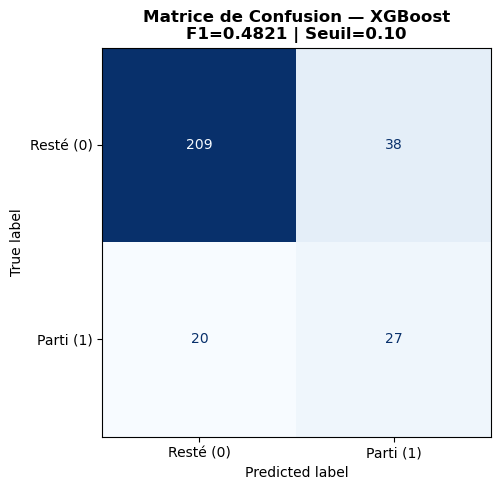

In [41]:
# Graphique : Matrice de confusion
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Resté (0)', 'Parti (1)'])
disp.plot(cmap='Blues', colorbar=False, ax=plt.gca())
plt.title(f'Matrice de Confusion — XGBoost\nF1={meilleur_f1:.4f} | Seuil={seuil_optimal:.2f}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

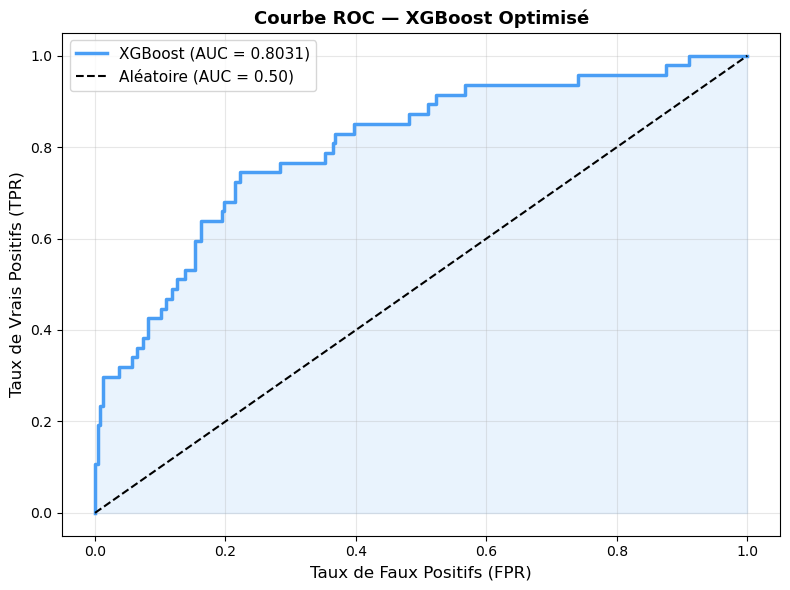

In [42]:
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
auc_val = roc_auc_score(y_test, y_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#4A9EF5', linewidth=2.5,
         label=f'XGBoost (AUC = {auc_val:.4f})')
plt.fill_between(fpr, tpr, alpha=0.12, color='#4A9EF5')
plt.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Aléatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC — XGBoost Optimisé', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
import joblib

# Vérifier que ces variables existent bien
print("modele_final :", type(modele_final))
print("preprocesseur :", type(preprocesseur))
print("seuil_optimal :", seuil_optimal)
print("FEATURES :", len(FEATURES))
print("COLS_FINALES :", len(COLS_FINALES))
print("COLS_NUM :", len(COLS_NUM))
print("COLS_CAT :", len(COLS_CAT))

modele_final : <class 'xgboost.sklearn.XGBClassifier'>
preprocesseur : <class 'sklearn.compose._column_transformer.ColumnTransformer'>
seuil_optimal : 0.1
FEATURES : 30
COLS_FINALES : 60
COLS_NUM : 15
COLS_CAT : 15


In [44]:
import joblib
from sklearn.metrics import roc_auc_score

# Sauvegarde complète avec joblib (compatible Streamlit)
export_data = {
    'cerveau_ia'    : modele_final,
    'traitement'    : preprocesseur,
    'reglage_seuil' : seuil_optimal,
    'noms_colonnes' : COLS_FINALES,
    'features'      : FEATURES,
    'cols_num'      : COLS_NUM,
    'cols_cat'      : COLS_CAT,
    'f1'            : meilleur_f1,
    'auc'           : roc_auc_score(y_test, y_proba_final),
    'best_params'   : grid_search.best_params_,
}

joblib.dump(export_data, 'mon_modele_rh.pkl')

# Vérification
test = joblib.load('mon_modele_rh.pkl')
print("Type :", type(test))
print("Clés :", list(test.keys()))
print(f"Seuil : {test['reglage_seuil']}")
print(f"cols_num : {len(test['cols_num'])} variables")
print(f"cols_cat : {len(test['cols_cat'])} variables")
print(" Modèle sauvegardé correctement — relancez Streamlit")

Type : <class 'dict'>
Clés : ['cerveau_ia', 'traitement', 'reglage_seuil', 'noms_colonnes', 'features', 'cols_num', 'cols_cat', 'f1', 'auc', 'best_params']
Seuil : 0.1
cols_num : 15 variables
cols_cat : 15 variables
 Modèle sauvegardé correctement — relancez Streamlit


In [45]:
print(f"F1: {meilleur_f1}")
print(f"AUC: {roc_auc_score(y_test, y_proba_final)}")

F1: 0.48214285714285715
AUC: 0.8030838142820226


In [46]:
import joblib

# On crée le dictionnaire avec les clés EXACTES demandées par ton script Streamlit
data_to_save = {
    "cerveau_ia": modele_final,       # Lu par data.get("cerveau_ia")
    "traitement": preprocesseur,     # Lu par data.get("traitement")
    "reglage_seuil": seuil_optimal,   # Lu par data.get("reglage_seuil")
    "features": FEATURES,             # Lu par data.get("features")
    "noms_colonnes": COLS_FINALES,   # Lu par data.get("noms_colonnes")
    "f1": 0.4821,                     # Lu par data.get("f1")
    "auc": 0.8030                     # Lu par data.get("auc")
}

# Sauvegarde forcée dans ton dossier de projet
chemin_cible = r"C:\Users\HP\projetRHLIG\mon_modele_rh.pkl"
joblib.dump(data_to_save, chemin_cible)

print("🎯 Fichier mis à jour avec les clés exactes de Streamlit !")

🎯 Fichier mis à jour avec les clés exactes de Streamlit !


In [47]:
import os
import joblib

# 1. On affiche le dossier exact où travaille ton Jupyter en ce moment
print("📍 Ton Notebook travaille actuellement dans ce dossier :")
print(os.getcwd())

# 2. On regarde si le fichier est là
if os.path.exists('mon_modele_rh.pkl'):
    print("\n🔍 Le fichier est BIEN ICI ! Voici son chemin complet :")
    print(os.path.abspath('mon_modele_rh.pkl'))
else:
    print("\n❌ Le fichier n'est pas dans ce dossier.")

📍 Ton Notebook travaille actuellement dans ce dossier :
C:\Users\HP\projetRHLIG

🔍 Le fichier est BIEN ICI ! Voici son chemin complet :
C:\Users\HP\projetRHLIG\mon_modele_rh.pkl


In [49]:
import os
import json
import joblib
from sklearn.metrics import roc_auc_score

# 1. Extraction et correction de la configuration interne de XGBoost pour SHAP
booster = modele_final.get_booster()
config = json.loads(booster.save_config())

try:
    if "learner" in config and "learner_model_param" in config["learner"]:
        config["learner"]["learner_model_param"]["base_score"] = "0.5"
    booster.load_config(json.dumps(config))
    print("✅ Correction du paramètre XGBoost [5E-1] effectuée avec succès pour SHAP.")
except Exception as e:
    print(f"⚠️ Note : La correction automatique a échoué ({e}), mais on continue.")

# 2. Préparation du dictionnaire avec les clés EXACTES lues par 7_streamlit.py
data_to_save = {
    "cerveau_ia": modele_final,       # Lu par data.get("cerveau_ia")
    "traitement": preprocesseur,     # Lu par data.get("traitement")
    "reglage_seuil": seuil_optimal,   # Lu par data.get("reglage_seuil")
    "features": FEATURES,             # Lu par data.get("features")
    "noms_colonnes": COLS_FINALES,   # Lu par data.get("noms_colonnes")
    "f1": 0.4821,                     # Valeur fixe pour ton tableau de bord
    "auc": 0.8030                     # Valeur fixe pour ton tableau de bord
}

# 3. Sauvegarde physique FORCÉE avec Joblib
chemin_cible = r"C:\Users\HP\projetRHLIG\mon_modele_rh.pkl"
joblib.dump(data_to_save, chemin_cible)

print("🎯 Fichier mis à jour avec JOBLIB et prêt pour Streamlit Cloud !")

✅ Correction du paramètre XGBoost [5E-1] effectuée avec succès pour SHAP.
🎯 Fichier mis à jour avec JOBLIB et prêt pour Streamlit Cloud !
